In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Data load

In [3]:
df = pd.read_csv("F:/DTU/02582 Computational Data Analysis/case2/HR_data_2/HR_data_2.csv")  
df = df.iloc[:, 1:]

# columns
meta_cols = [
    'Round', 'Phase', 'Individual', 'Puzzler',
    'original_ID', 'raw_data_path', 'Team_ID', 'Cohort'
]

questionnaire_cols = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed',
    'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined'
]

feature_cols = [
    c for c in df.columns
    if c not in meta_cols + questionnaire_cols
]



print(f"length:     {len(df)}")
print(f"feature columns:   {len(feature_cols)}")
print(f"meta columns: {len(meta_cols)}")
print(f"questionnaire columns:   {len(questionnaire_cols)}")
print(f"\nPhase distribution:\n{df['Phase'].value_counts()}")
print(f"\nNumber of individual: {df['Individual'].nunique()}")

length:     312
feature columns:   51
meta columns: 8
questionnaire columns:   11

Phase distribution:
phase3    104
phase2    104
phase1    104
Name: Phase, dtype: int64

Number of individual: 26


# 2. Missing value

In [5]:
missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'number of missing values': missing,
    'fraction of missing values(%)': missing_pct
})
missing_with_issues = missing_summary[missing_summary['number of missing values'] > 0]

if len(missing_with_issues) == 0:
    print("No missing values")
else:
    print(missing_with_issues)


              number of missing values  fraction of missing values(%)
EDA_TD_P_RT                          1                           0.32
EDA_TD_P_ReT                         1                           0.32


In [6]:
# print the missing sample
mask_missing = df['EDA_TD_P_RT'].isna() | df['EDA_TD_P_ReT'].isna()
print(df.loc[mask_missing, ['Individual', 'Round', 'Phase', 
                             'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT']])

     Individual    Round   Phase  EDA_TD_P_Peaks  EDA_TD_P_RT  EDA_TD_P_ReT
272          23  round_4  phase1               1          NaN           NaN


In [45]:
df['EDA_TD_P_RT'].fillna(0, inplace=True)
df['EDA_TD_P_ReT'].fillna(0, inplace=True)

# 3. Featrue selection

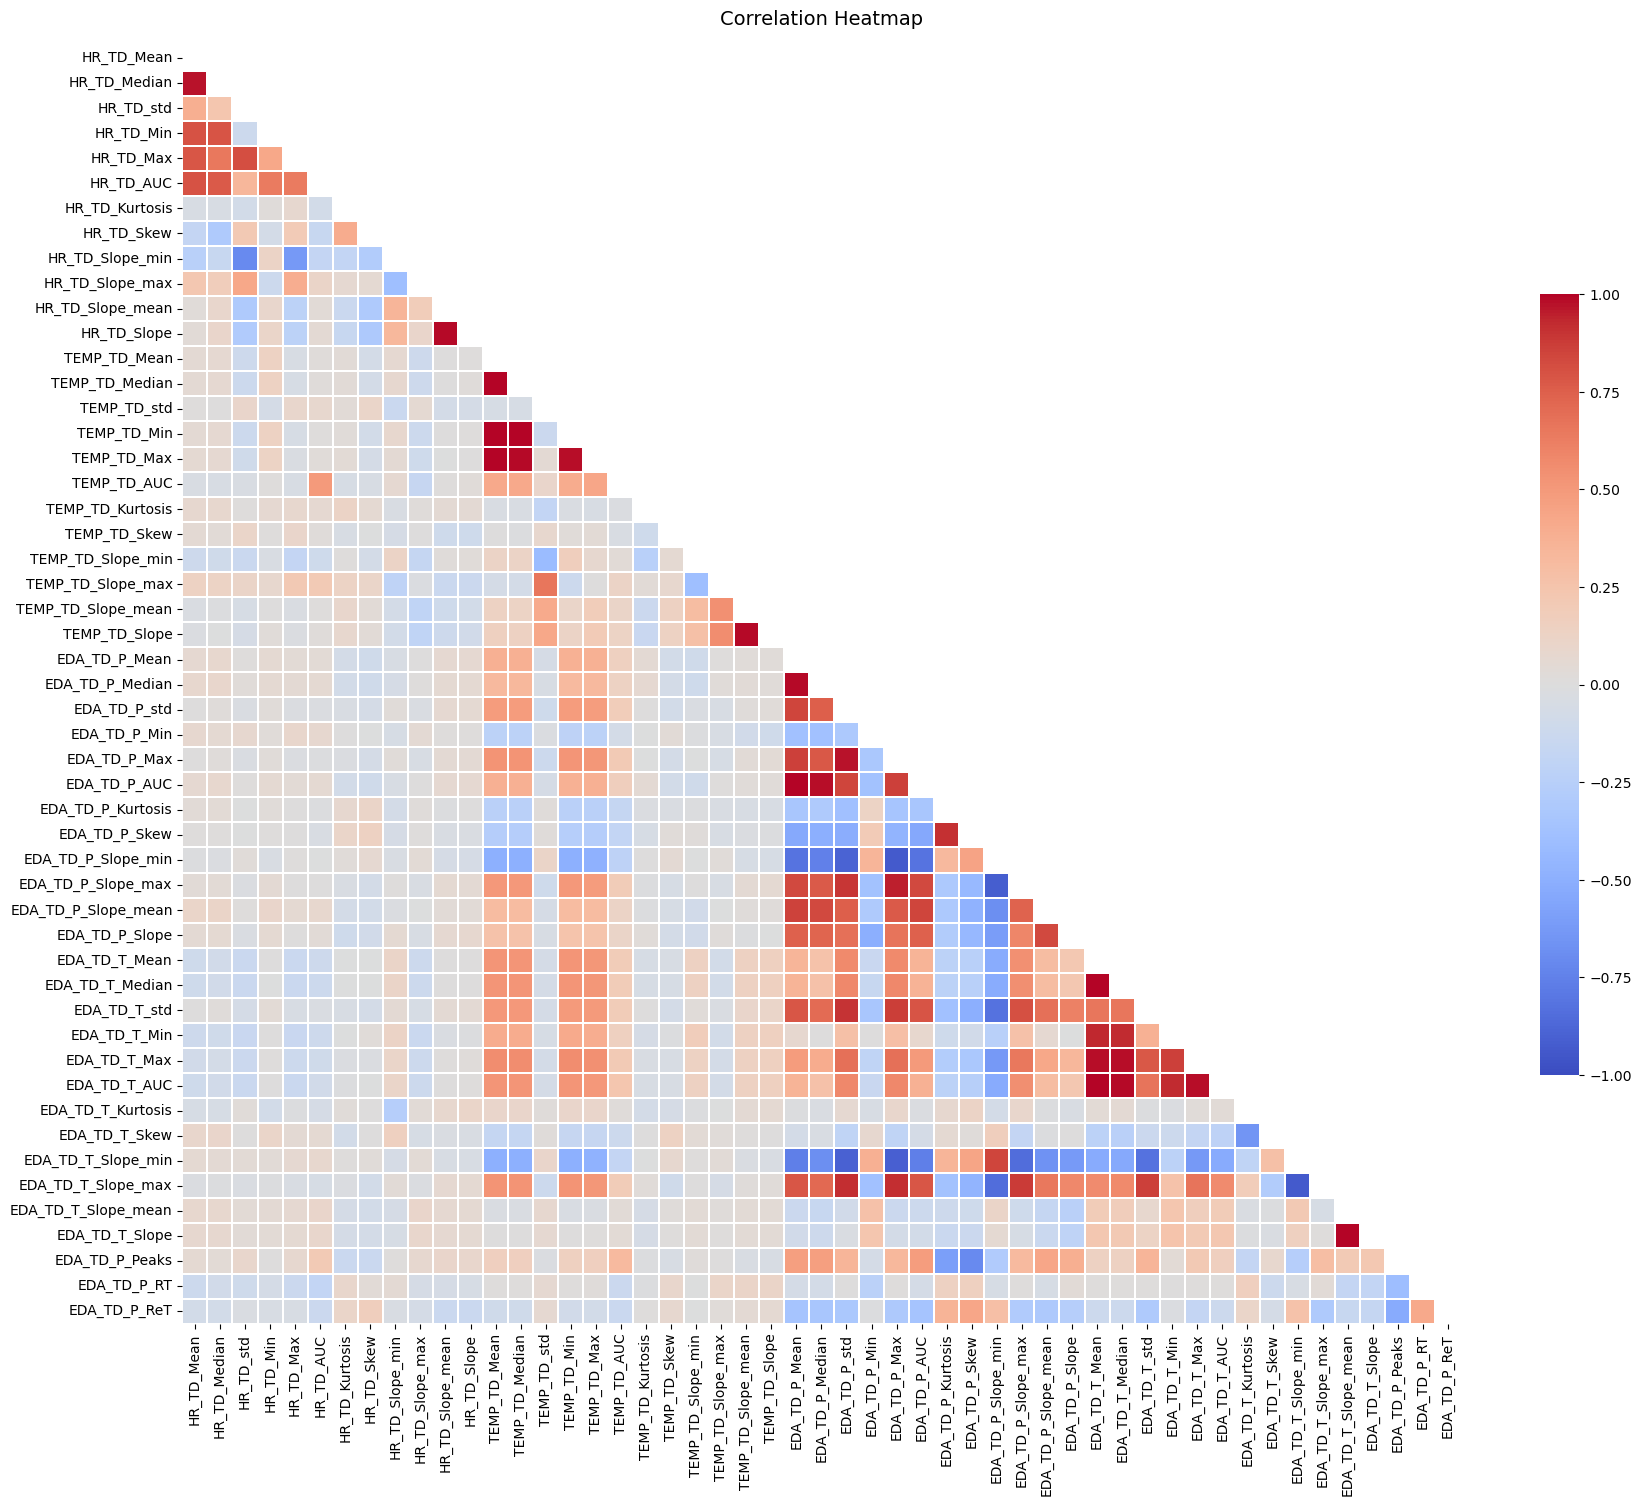

In [ ]:
# correlation heatmap
fig, ax = plt.subplots(figsize=(18, 15))
corr_matrix = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 只显示下三角
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"shrink": 0.6}
)
ax.set_title("Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [8]:
# print high related features（r > 0.9）
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

print(f"\n|r| > 0.9 {len(high_corr_pairs)} ：")

for a, b, r in high_corr_pairs:  
    print(f"  {a}  ↔  {b}  (r={r})")


|r| > 0.9 32 ：
  HR_TD_Mean  ↔  HR_TD_Median  (r=0.971)
  HR_TD_Slope_mean  ↔  HR_TD_Slope  (r=0.988)
  TEMP_TD_Mean  ↔  TEMP_TD_Median  (r=1.0)
  TEMP_TD_Mean  ↔  TEMP_TD_Min  (r=0.996)
  TEMP_TD_Mean  ↔  TEMP_TD_Max  (r=0.994)
  TEMP_TD_Median  ↔  TEMP_TD_Min  (r=0.995)
  TEMP_TD_Median  ↔  TEMP_TD_Max  (r=0.992)
  TEMP_TD_Min  ↔  TEMP_TD_Max  (r=0.982)
  TEMP_TD_Slope_mean  ↔  TEMP_TD_Slope  (r=0.986)
  EDA_TD_P_Mean  ↔  EDA_TD_P_Median  (r=0.985)
  EDA_TD_P_Mean  ↔  EDA_TD_P_AUC  (r=0.999)
  EDA_TD_P_Median  ↔  EDA_TD_P_AUC  (r=0.983)
  EDA_TD_P_std  ↔  EDA_TD_P_Max  (r=0.973)
  EDA_TD_P_std  ↔  EDA_TD_T_Slope_min  (r=-0.903)
  EDA_TD_P_std  ↔  EDA_TD_T_Slope_max  (r=0.915)
  EDA_TD_P_Max  ↔  EDA_TD_P_Slope_min  (r=-0.935)
  EDA_TD_P_Max  ↔  EDA_TD_P_Slope_max  (r=0.948)
  EDA_TD_P_Max  ↔  EDA_TD_T_Slope_min  (r=-0.907)
  EDA_TD_P_Max  ↔  EDA_TD_T_Slope_max  (r=0.918)
  EDA_TD_P_Kurtosis  ↔  EDA_TD_P_Skew  (r=0.914)
  EDA_TD_P_Slope_min  ↔  EDA_TD_P_Slope_max  (r=-0.922)
  EDA_TD_

In [9]:
# select features
selected_features = [
    # HR（6）
    'HR_TD_Mean', 'HR_TD_std', 'HR_TD_Slope',
    'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew',
    # TEMP（5）
    'TEMP_TD_Mean', 'TEMP_TD_Slope', 'TEMP_TD_AUC',
    'TEMP_TD_Kurtosis', 'TEMP_TD_Skew',
    # EDA Phasic（7）
    'EDA_TD_P_Mean', 'EDA_TD_P_std', 'EDA_TD_P_Slope',
    'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT',
    'EDA_TD_P_Skew',
    # EDA Tonic（4）
    'EDA_TD_T_Mean', 'EDA_TD_T_Slope',
    'EDA_TD_T_Kurtosis', 'EDA_TD_T_Skew',
]

selected_features_13 = [
    # HR（4）
    'HR_TD_Mean', 'HR_TD_std', 'HR_TD_Slope', 'HR_AUC', 

    # TEMP（3）
    'TEMP_TD_Mean', 'TEMP_TD_Slope', 'TEMP_AUC',

    # EDA Phasic（6）
    'EDA_TD_P_Mean', 'EDA_TD_P_std',
    'EDA_TD_P_Slope', 'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_Skew',

    # EDA Tonic（2）
    'EDA_TD_T_Mean', 'EDA_TD_T_Slope',
]


# 4. Standardization

In [ ]:
def per_subject_zscore(df, feature_cols, subject_col='Individual'):
    """
    z-score standardization was performed independently for each participant
    To eliminate individual baseline differences, 
    and to preserve the relative changes of each individual across different phases.
    """
    df_scaled = df.copy()
    subjects = df[subject_col].unique()

    for subj in subjects:
        mask = df[subject_col] == subj
        subj_data = df.loc[mask, feature_cols]


        scaler = StandardScaler()
        df_scaled.loc[mask, feature_cols] = scaler.fit_transform(subj_data)

    return df_scaled

df_scaled_basic = per_subject_zscore(df, selected_features)


print(df_scaled_basic[selected_features].describe().round(3).loc[['mean', 'std']])

      HR_TD_Mean  HR_TD_std  HR_TD_Slope  HR_TD_AUC  HR_TD_Kurtosis  \
mean      -0.000      0.000        0.000     -0.000          -0.000   
std        1.002      1.002        1.002      1.002           1.002   

      HR_TD_Skew  TEMP_TD_Mean  TEMP_TD_Slope  TEMP_TD_AUC  TEMP_TD_Kurtosis  \
mean       0.000        -0.000         -0.000       -0.000             0.000   
std        1.002         1.002          1.002        1.002             1.002   

      ...  EDA_TD_P_std  EDA_TD_P_Slope  EDA_TD_P_Peaks  EDA_TD_P_RT  \
mean  ...        -0.000           0.000           0.000        0.000   
std   ...         1.002           1.002           1.002        1.002   

      EDA_TD_P_ReT  EDA_TD_P_Skew  EDA_TD_T_Mean  EDA_TD_T_Slope  \
mean         0.000          0.000          0.000           0.000   
std          1.002          1.002          1.002           1.002   

      EDA_TD_T_Kurtosis  EDA_TD_T_Skew  
mean              0.000          0.000  
std               1.002          1.002  


# 5. Visualization of preprocessed data

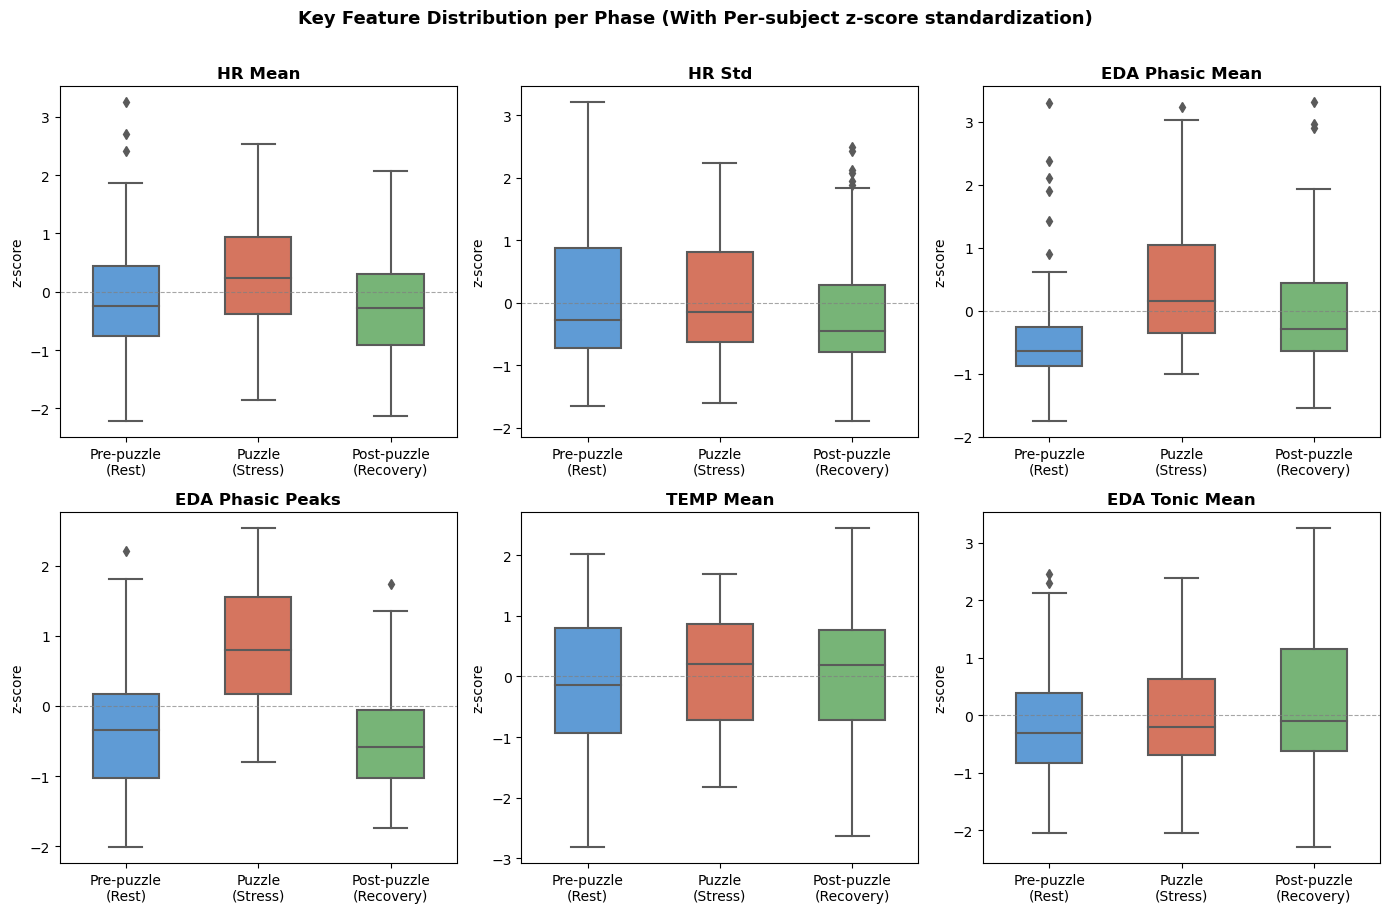

In [ ]:
phase_order = ['phase1', 'phase2', 'phase3']   
phase_labels_map = {
    'phase1': 'Pre-puzzle\n(Rest)',
    'phase2': 'Puzzle\n(Stress)',
    'phase3': 'Post-puzzle\n(Recovery)'
}

key_features_plot = [
    'HR_TD_Mean', 'HR_TD_std',
    'EDA_TD_P_Mean', 'EDA_TD_P_Peaks',
    'TEMP_TD_Mean', 'EDA_TD_T_Mean'
]
key_titles = [
    'HR Mean', 'HR Std',
    'EDA Phasic Mean', 'EDA Phasic Peaks',
    'TEMP Mean', 'EDA Tonic Mean'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, feat, title in zip(axes, key_features_plot, key_titles):
    plot_data = df_scaled_basic.copy()
    plot_data['Phase_label'] = plot_data['Phase'].map(phase_labels_map)

    sns.boxplot(
        data=plot_data,
        x='Phase_label',
        y=feat,
        order=[phase_labels_map.get(p, p) for p in phase_order
               if phase_labels_map.get(p, p) in plot_data['Phase_label'].unique()],
        palette=['#4C9BE8', '#E8694C', '#6DBE6D'],
        width=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('z-score')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

fig.suptitle(
    'Key Feature Distribution per Phase (With Per-subject z-score standardization)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()

plt.show()

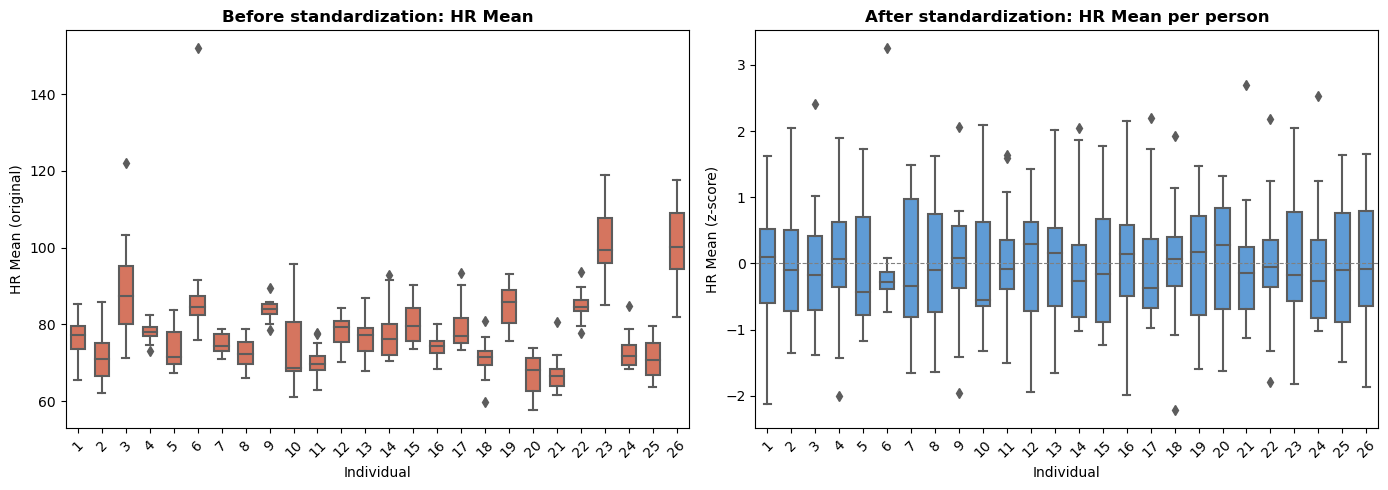

In [ ]:
# per-subject vs global standardization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# before standardization
sns.boxplot(
    data=df,
    x='Individual',
    y='HR_TD_Mean',
    ax=axes[0],
    color='#E8694C',
    width=0.6
)
axes[0].set_title('Before standardization: HR Mean', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Individual')
axes[0].set_ylabel('HR Mean (original)')
axes[0].tick_params(axis='x', rotation=45)

# after standardization
sns.boxplot(
    data=df_scaled_basic,
    x='Individual',
    y='HR_TD_Mean',
    ax=axes[1],
    color='#4C9BE8',
    width=0.6
)
axes[1].set_title('After standardization: HR Mean per person', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Individual')
axes[1].set_ylabel('HR Mean (z-score)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

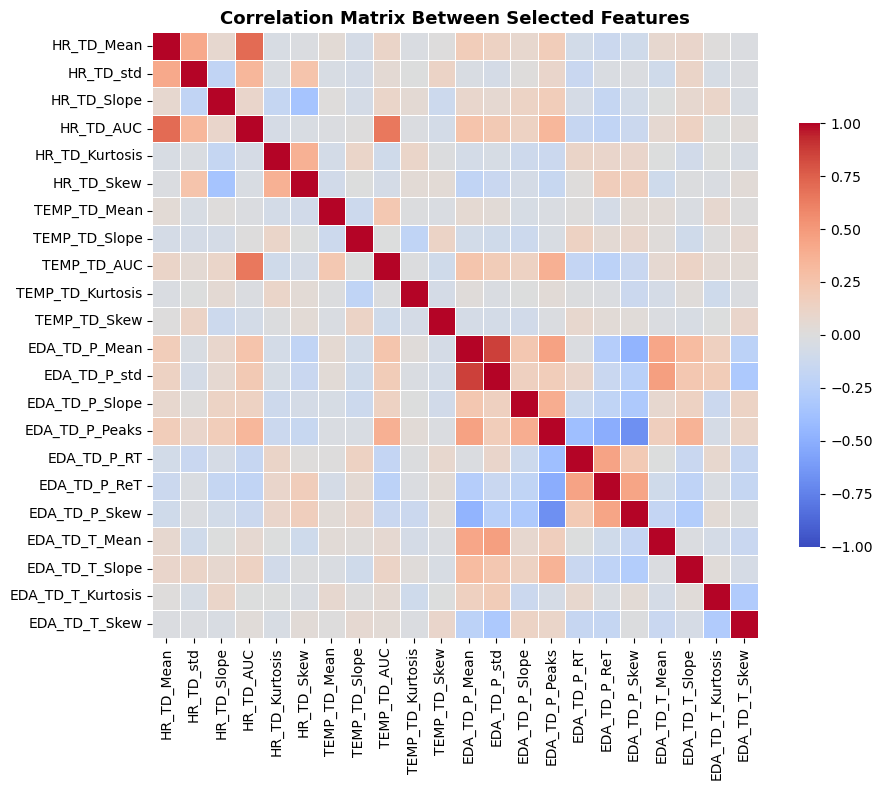

In [13]:
# heatmap of selected features
fig, ax = plt.subplots(figsize=(10, 8))
corr_selected = df_scaled_basic[selected_features].corr()
sns.heatmap(
    corr_selected,
    annot=False,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.7}
)
ax.set_title("Correlation Matrix Between Selected Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Save to csv

In [14]:
output_cols = selected_features + meta_cols + questionnaire_cols
data = df_scaled_basic[output_cols]
data.head()

,HR_TD_Mean,HR_TD_std,HR_TD_Slope,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,TEMP_TD_Mean,TEMP_TD_Slope,TEMP_TD_AUC,TEMP_TD_Kurtosis,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,0.369071,0.551587,1.076291,-0.105352,-0.697423,0.079325,0.955625,-1.232981,-0.292168,1.282230,...,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,-0.029258,-1.028737,-0.210537,0.433103,-0.065442,0.038070,0.676746,0.395407,0.877053,0.325060,...,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,0.277082,-0.997585,-0.244317,-1.714475,-0.342241,-0.717414,0.307934,-0.533003,-2.715544,-0.601620,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,1.196406,0.513996,0.618138,1.002815,-0.529486,-0.470299,-0.112678,1.477624,-0.205666,-1.056970,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,-0.828390,-0.832135,-0.005708,-0.103196,0.267492,-1.150665,-0.427606,-0.870508,0.860895,-1.009872,...,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0


In [15]:
data.to_csv("data_0425.csv", index=False)